## Finetune with LoRA

This notebook will finetune a pretrained instruct model with some preference data with the goal of obtaining a new model that resembles the prefer response type. This will use synthetic data that was generated by `generate_training_data.ipnyb`

In [38]:
import time
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import json
from huggingface_hub import login
from transformers import AutoTokenizer, AutoModelForCausalLM, DataCollatorWithPadding
import random
import torch.nn as nn
import math
from torch.nn.utils.rnn import pad_sequence
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

### Load data

In [2]:
PREFERENCE_DATA = 'questions_preference.json'

with open(PREFERENCE_DATA, 'r') as f:
    data = json.load(f)

In [3]:
data[0]

{'question': 'What are the signs of a toxic partner?',
 'rejected': "Identifying a toxic partner can be challenging, but being aware of these common signs can help you recognize the warning signs and take necessary steps to protect yourself. Here are some common indicators of a toxic partner:\n\n1. **Controlling behavior**: They try to control what you wear, who you hang out with, or what you do.\n2. **Emotional manipulation**: They use guilt, anger, or self-pity to make you feel bad about yourself or your choices.\n3. **Verbal abuse**: They regularly use put-downs, insults, or name-calling to belittle you.\n4. **Gaslighting**: They deny previous agreements or conversations, making you question your own memory or sanity.\n5. **Isolation**: They isolate you from friends and family, making it difficult for you to have a support network.\n6. **Possessiveness**: They become overly possessive, jealous, or insecure when you spend time with others.\n7. **Disrespect**: They consistently disres

In [4]:
# Remove 'rejected' from question - This is for DPO
questions = [{k:v for k,v in q.items() if k != 'rejected'} for q in data]

In [5]:
# The prompt to generate the data can be found in the generate training data notebook
# The goal was to generate data with the model assuming a specific role/style
# The objective is to train a base model to generate response that resemble this style

questions[0]

{'question': 'What are the signs of a toxic partner?',
 'chosen': "You want to know if you're dealing with a lemon or a genius. Signs of a toxic partner: constant criticism (not constructive), gaslighting (denying reality), emotional manipulation, jealousy that borders on obsession, disregard for boundaries, and making you feel bad about yourself. Oh, and they never take responsibility for their actions.\n\nNow, if you're still with them after these red flags are waving in your face, it's time to reevaluate the relationship. Trust me, I've got a better design for your life."}

### Import model

We will use a llama 3b parameter model for the finetuning

In [6]:
# Llama model requires license agreement
# https://huggingface.co/meta-llama/Llama-3.2-3B-Instruct
access_token = '<access_token>'
login(token=access_token)

In [7]:
# Running on Apple silicon device
device = torch.device('mps' if torch.mps.is_available() else 'cpu')

print('Device', device)

Device mps


In [8]:
model_name = 'meta-llama/Llama-3.2-1B-Instruct'

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16 # due to hardware constraints
)

model.to(device)

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|███████████████████████| 146/146 [00:00<00:00, 246.14it/s]


LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (ro

In [10]:
# test model
messages = [
    {"role": "user", "content": "What is the capital of Spain?"}
]

inputs = tokenizer.apply_chat_template(
    messages,
    return_tensors="pt",
    add_generation_prompt=True
)

inputs = inputs.to("mps")

output = model.generate(
    **inputs,
    max_new_tokens=50
)

print(tokenizer.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 06 Mar 2026

user

What is the capital of Spain?assistant

The capital of Spain is Madrid.


In [11]:
### Some prompts to test behavior of the model before and after training

test_prompts = [
    'What is the best way to cook fried eggs?',
    'How can I recover after a workout?',
    'Can you help understand how the Roman Empire lost its power?'
]

for prompt in test_prompts:
    messages = [
        {"role": "user", "content": prompt}
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        return_tensors="pt",
        add_generation_prompt=True
    )
    
    inputs = inputs.to("mps")
    
    output = model.generate(
        **inputs,
        max_new_tokens=250
    )
    
    print(tokenizer.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 06 Mar 2026

user

What is the best way to cook fried eggs?assistant

There are several ways to cook fried eggs, and the best method for you will depend on your personal preference and the equipment you have available. Here are a few popular methods:

1. **Pan-frying**: This is a classic method for cooking fried eggs. Heat a non-stick pan over medium heat, add a small amount of oil or butter, and crack an egg into the pan. Cook until the whites are set and the yolks are cooked to your desired doneness.
2. **Skillet-frying**: Similar to pan-frying, but use a larger skillet to cook multiple eggs at once. This method is great for making omelets or scrambled eggs.
3. **Oven-frying**: This method involves cooking eggs in the oven. Crack an egg into a baking dish or ramekin, add a small amount of oil or butter, and bake at 375°F (190°C) for 8-12 minutes, or until the whites are set and the yolks are cooked to your desired doneness.
4.

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 06 Mar 2026

user

How can I recover after a workout?assistant

Recovering after a workout is essential to allow your body to repair and rebuild muscle tissue, replenish energy stores, and prevent injury. Here are some tips to help you recover after a workout:

1. **Hydrate**: Drink plenty of water or a sports drink to replenish lost fluids and electrolytes. Aim to drink at least 8-10 glasses of fluid per day.
2. **Post-Workout Nutrition**: Consume a balanced meal or snack that includes protein, carbohydrates, and healthy fats within 30-60 minutes after your workout. This can help promote muscle recovery and growth.
3. **Rest and Relaxation**: Allow your body time to rest and recover. Aim for 7-9 hours of sleep per night to help your body repair and rebuild muscle tissue.
4. **Stretching and Foam Rolling**: Gentle stretching and foam rolling can help reduce muscle soreness and improve flexibility. Focus on major muscle groups li

### Prepare Dataset

In [12]:
def preprocess_dataset(data, tokenizer, max_length=256):
    processed = []

    for item in data:
        messages = [
            {'role': 'user', 'content': item['question']},
            {'role': 'assistant', 'content': item['chosen']}
        ]

        prompt_message = [
            {'role': 'user', 'content': item['question']}
        ]

        # Adds expected prompt format for instruct model
        tokens = tokenizer.apply_chat_template(
            messages,
            tokenize=True,
            return_tensors='pt',
            padding=False,
            truncation=True,
            max_length=max_length
        )

        # Remove batch dimension added from tokenizer
        input_ids = tokens["input_ids"].squeeze(0)
        attention_mask = tokens["attention_mask"].squeeze(0)

        labels = input_ids.clone()

        # Get prompt-only tokens
        prompt_tokens = tokenizer.apply_chat_template(
            prompt_message,
            tokenize=True,
            add_generation_prompt=True,
            return_tensors='pt'
        )

        prompt_length = prompt_tokens['input_ids'].shape[1]

        # Mask prompt and padding
        labels[:prompt_length] = -100
        labels[attention_mask == 0] = -100

        processed.append({
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels
        })

    return processed

In [13]:
class LoRADataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [14]:
print(f'Number of questions {len(questions):,}')

random.seed(123)
random.shuffle(questions)

len_train = int(len(questions) * 0.85)
len_test = int(len(questions) * 0.1)

train_questions = questions[:len_train]
test_questions = questions[len_train:len_train+len_test]
val_questions = questions[len_train+len_test:]

print(f'Train data: {len(train_questions):,}')
print(f'Val data: {len(val_questions):,}')
print(f'Test data: {len(test_questions):,}')

Number of questions 14,023
Train data: 11,919
Val data: 702
Test data: 1,402


In [15]:
# Sequence will be truncated but this is a hardware limitation
max_length=256

# preprocess data to improve performance instead of tokenizing every batch
train_data_processed = preprocess_dataset(train_questions, tokenizer, max_length=max_length)
val_data_processed = preprocess_dataset(val_questions, tokenizer, max_length=max_length)
test_data_processed = preprocess_dataset(test_questions, tokenizer, max_length=max_length)

train_dataset = LoRADataset(train_data_processed)
val_dataset = LoRADataset(val_data_processed)
test_dataset = LoRADataset(test_data_processed)

In [16]:
# Test dataset
sample = train_dataset[0]
print(tokenizer.decode(sample['input_ids']))
print(sample['labels'])

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 06 Mar 2026

<|eot_id|><|start_header_id|>user<|end_header_id|>

None<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Looks like you're ready for something. What's on your mind? Need help with a project or just wanna bounce some ideas off me?<|eot_id|>
tensor([  -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
          -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
          -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
          -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
         59844,   1093,    499,   2351,   5644,    369,   2555,     13,   3639,
           596,    389,    701,   4059,     30,  14998,   1520,    449,    264,
          2447,    477,   1120,  33833,  34782,   1063,   6848,   1022,    757,
            30, 128009])


In [17]:
class CausalLMCollator:
    def __init__(self, tokenizer):
        self.pad_token_id = tokenizer.pad_token_id

    def __call__(self, features):
        input_ids = [f["input_ids"] for f in features]
        attention_mask = [f["attention_mask"] for f in features]
        labels = [f["labels"] for f in features]

        input_ids = pad_sequence(
            input_ids, batch_first=True, padding_value=self.pad_token_id
        )

        attention_mask = pad_sequence(
            attention_mask, batch_first=True, padding_value=0
        )

        labels = pad_sequence(
            labels, batch_first=True, padding_value=-100
        )

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
        }

In [18]:
batch_size = 4

collator = CausalLMCollator(tokenizer)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    collate_fn=collator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collator
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collator
)

In [18]:
# Test batches
print(f'{len(train_loader)} training batches')

batch = next(iter(train_loader))
print(batch['input_ids'].shape)
print(batch['labels'].shape)

2979 training batches
torch.Size([4, 256])
torch.Size([4, 256])


### Prepare the model with LoRA layers

In [20]:
# Note: PEFT package could be used here instead. Applying LoRA manually for learning purposes
class LoRALayer(nn.Module):
    def __init__(self, in_dim, out_dim, rank, alpha):
        super().__init__()
        self.A = nn.Linear(in_dim, rank, bias=False)
        self.B = nn.Linear(rank, out_dim, bias=False)

        nn.init.kaiming_uniform_(self.A.weight)
        nn.init.zeros_(self.B.weight)
        
        self.scale = alpha / rank

    def forward(self, x):
        x = self.A(x)
        x = self.B(x)
        return self.scale * x

In [21]:
class LinearWithLoRA(nn.Module):
    def __init__(self, linear, rank, alpha):
        super().__init__()
        self.linear = linear
        self.lora = LoRALayer(linear.in_features, linear.out_features, rank, alpha)

    def forward(self, x):
        return self.linear(x) + self.lora(x)

In [22]:
def replace_linear_layers_with_lora_layers(model, rank, alpha):
    for name, module in model.named_children():
        if isinstance(module, torch.nn.Linear):
            setattr(model, name, LinearWithLoRA(module, rank, alpha))
        else:
            replace_linear_layers_with_lora_layers(module, rank, alpha)

In [23]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable_params:,}')

for p in model.parameters():
    p.requires_grad = False

# Should be 0
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable_params}')

# Following standard rank 8 and alpha 2 x rank (also 8 due to hardware limitation)
replace_linear_layers_with_lora_layers(model, rank=8, alpha=16)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable_params:,}')

Trainable parameters: 1,235,814,400
Trainable parameters: 0
Trainable parameters: 6,678,528


## Finetune the model

#### Prepare training method

In [24]:
def train_lora_model(model, train_loader, val_loader, num_epochs, optimizer, eval_freq,
                     eval_batches, device, warmup_steps, initial_lr, min_lr, control_lr=True):
    train_losses, val_losses = [], []
    tokens_seen = 0
    global_step = -1

    if control_lr:
        peak_lr = optimizer.param_groups[0]['lr']
        total_training_steps = len(train_loader) * num_epochs
        lr_increment = (peak_lr - initial_lr) / warmup_steps

    for epoch in range(num_epochs):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()

            if control_lr:
                # Warmup for first 20% of training, then cosine annealing
                if global_step < warmup_steps:
                    lr = initial_lr + global_step * lr_increment
                else:
                    progress = ((global_step - warmup_steps)/
                                (total_training_steps - warmup_steps))
                    lr = (
                        min_lr + (peak_lr - min_lr) * 0.5 *
                        (1 + math.cos(math.pi * progress))
                    )

                for param_group in optimizer.param_groups:
                    param_group['lr'] = lr

            input_batch = batch['input_ids'].to(device)
            target_batch = batch['labels'].to(device)
            mask_batch = batch['attention_mask'].to(device)

            outputs = model(
                input_ids=input_batch,
                attention_mask=mask_batch,
                labels=target_batch
            )

            outputs.loss.backward()
            optimizer.step()
            
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_batches
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f'Epoch {epoch+1} (Step {global_step:06d}) '
                      f'Train loss: {train_loss:.3f} Val loss: {val_loss:.3f}')

        # generate example after each epoch
        generate_response(model, tokenizer, device)

    return train_losses, val_losses, tokens_seen

In [25]:
def evaluate_model(model, train_loader, val_loader, device, eval_batches):
    model.eval()

    with torch.no_grad():
        train_loss = calculate_loader_loss(model, train_loader, device, eval_batches)
        val_loss = calculate_loader_loss(model, val_loader, device, eval_batches)
        
    model.train()
    return train_loss, val_loss

In [26]:
def calculate_loader_loss(model, loader, device, eval_batches=None):
    if eval_batches is None:
        num_batches = len(loader)
    else:
        num_batches = min(eval_batches, len(loader))

    loss = 0

    for i, batch in enumerate(loader):
        if i < num_batches:
            input_batch = batch['input_ids'].to(device)
            target_batch = batch['labels'].to(device)
            mask_batch = batch['attention_mask'].to(device)
    
            output = model(
                input_ids=input_batch,
                labels=target_batch,
                attention_mask=mask_batch
            )
    
            loss += output.loss.item()
        else:
            break

    return loss / num_batches        

In [27]:
def generate_response(model, tokenizer, device):
    prompt = 'What is the best way to cook fried eggs?'

    messages = [
        {"role": "user", "content": prompt}
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        return_tensors="pt",
        add_generation_prompt=True
    )
    
    inputs = inputs.to(device)
    
    output = model.generate(
        **inputs,
        max_new_tokens=250
    )
        
    print(tokenizer.decode(output[0], skip_special_tokens=True))

#### Training

In [28]:
torch.manual_seed(123)

model.to(device)

num_epochs = 5
total_steps = len(train_loader) * num_epochs
warmup_steps = int(0.2 * total_steps)
control_lr = True

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=0.1)

start_time = time.time()

train_losses, val_losses, tokens_seen = train_lora_model(
    model, train_loader, val_loader, num_epochs, optimizer, eval_freq=50, eval_batches=10,
    device=device, warmup_steps=warmup_steps, initial_lr=1e-5, min_lr=1e-6, control_lr=control_lr
)

end_time = time.time()

print(f'Training completed in {((end_time - start_time)/60):.2f} minutes')
print(f'Total tokens seen: {tokens_seen:,}')

Epoch 1 (Step 000000) Train loss: 1.897 Val loss: 1.864
Epoch 1 (Step 000050) Train loss: 1.392 Val loss: 1.431
Epoch 1 (Step 000100) Train loss: 1.282 Val loss: 1.328
Epoch 1 (Step 000150) Train loss: 1.280 Val loss: 1.305
Epoch 1 (Step 000200) Train loss: 1.242 Val loss: 1.289
Epoch 1 (Step 000250) Train loss: 1.241 Val loss: 1.282
Epoch 1 (Step 000300) Train loss: 1.225 Val loss: 1.276
Epoch 1 (Step 000350) Train loss: 1.275 Val loss: 1.278
Epoch 1 (Step 000400) Train loss: 1.252 Val loss: 1.272
Epoch 1 (Step 000450) Train loss: 1.229 Val loss: 1.264
Epoch 1 (Step 000500) Train loss: 1.192 Val loss: 1.263
Epoch 1 (Step 000550) Train loss: 1.218 Val loss: 1.262
Epoch 1 (Step 000600) Train loss: 1.186 Val loss: 1.256
Epoch 1 (Step 000650) Train loss: 1.286 Val loss: 1.255
Epoch 1 (Step 000700) Train loss: 1.251 Val loss: 1.248
Epoch 1 (Step 000750) Train loss: 1.332 Val loss: 1.250
Epoch 1 (Step 000800) Train loss: 1.167 Val loss: 1.249
Epoch 1 (Step 000850) Train loss: 1.214 Val loss

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 06 Mar 2026

user

What is the best way to cook fried eggs?assistant

You want to know the secret to perfecting that golden-brown, runny-yolked masterpiece? It's not rocket science (okay, maybe a little), but I'll give you the lowdown.

First, use room temperature eggs for better texture. Then, heat your oil in a pan over medium heat – not too hot, not too cold. You want it to be just right, like Goldilocks.

Now, here's the trick: cook for about 2-3 minutes on the first side, then flip and cook for another 30 seconds to 1 minute on the second side. You'll know it's done when the whites are set and the yolks are still runny – don't overthink it, just eyeball it.

And voilà! You've got yourself a perfectly cooked fried egg, every time.
Epoch 2 (Step 003000) Train loss: 1.128 Val loss: 1.251
Epoch 2 (Step 003050) Train loss: 1.068 Val loss: 1.252
Epoch 2 (Step 003100) Train loss: 0.956 Val loss: 1.256
Epoch 2 (Step 003150) Train l

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 06 Mar 2026

user

What is the best way to cook fried eggs?assistant

The eternal question. You want to know the secret to a perfect fried egg. Alright, here's the deal: you gotta crack 'em into a hot skillet (not too hot, mind you) with some oil or butter. Let 'em cook for about 2-3 minutes on the first side, then flip 'em over and cook for another minute. Voilà! Golden brown, runny yolk, and a dash of genius.

Now, if you want to get fancy, try using a thermometer (it's 165°F for perfect doneness). But honestly, if it's not a little greasy, it's probably not done right.
Epoch 3 (Step 006000) Train loss: 0.821 Val loss: 1.306
Epoch 3 (Step 006050) Train loss: 0.817 Val loss: 1.303
Epoch 3 (Step 006100) Train loss: 0.841 Val loss: 1.318
Epoch 3 (Step 006150) Train loss: 0.846 Val loss: 1.305
Epoch 3 (Step 006200) Train loss: 0.838 Val loss: 1.318
Epoch 3 (Step 006250) Train loss: 0.815 Val loss: 1.317
Epoch 3 (Step 006300) Train

...

system

Cutting Knowledge Date: December 2023
Today Date: 07 Mar 2026

user

What is the best way to cook fried eggs?assistant

You want to know the secret to not turning your eggs into rubbery pancakes? Alright, listen up. I'm a fan of the "sunny-side up" method: crack 'em in a hot skillet (around 375°F), let 'em set for 30 seconds, then flip 'em over and cook for another 15-20 seconds. That's it. No need for all that fancy-schmancy "over-easy" nonsense. Just simple, effective cooking.
Epoch 4 (Step 008950) Train loss: 0.623 Val loss: 1.358
Epoch 4 (Step 009000) Train loss: 0.640 Val loss: 1.403
Epoch 4 (Step 009050) Train loss: 0.662 Val loss: 1.415
Epoch 4 (Step 009100) Train loss: 0.603 Val loss: 1.434
Epoch 4 (Step 009150) Train loss: 0.588 Val loss: 1.434
Epoch 4 (Step 009200) Train loss: 0.612 Val loss: 1.420
Epoch 4 (Step 009250) Train loss: 0.641 Val loss: 1.428
Epoch 4 (Step 009300) Train loss: 0.561 Val loss: 1.443
Epoch 4 (Step 009350) Train loss: 0.582 Val loss: 1.444
Epoc

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 07 Mar 2026

user

What is the best way to cook fried eggs?assistant

You want to know my secret for perfect fried eggs? Alright, here's the deal: you gotta crack 'em in a hot skillet with just enough oil to coat the pan. Now, I know what you're thinking, "But what if I don't have any oil?" Well, that's where the magic happens. Use a non-stick pan or a cast iron skillet – either way, you'll be golden.

Here's the trick: crack an egg into the pan and let it set for about 30 seconds. Then, use a spatula to gently lift the edges of the egg with a fork, allowing the uncooked white to flow underneath. Don't overcook it; you want that runny center, baby!

Now, if you want to get fancy, try using a thermometer – aim for 375°F (190°C). That's where the magic happens, my friend!
Epoch 5 (Step 011950) Train loss: 0.404 Val loss: 1.538
Epoch 5 (Step 012000) Train loss: 0.497 Val loss: 1.552
Epoch 5 (Step 012050) Train loss: 0.491 Val loss:

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 07 Mar 2026

user

What is the best way to cook fried eggs?assistant

The eternal question. I've got it down to three methods: 

1. **Sunny-side up**: Simple, yet elegant. Just crack 'em into a hot skillet greased with butter or oil, let the whites set, and voilà!
2. **Soft-boiled with a twist**: Boil for 3-4 minutes, thenShock them in an ice bath. This will give you a runny yolk without overcooking the whites.
3. **Pan-seared with a sizzle**: Crack 'em into a hot skillet coated with oil or butter, let the eggs set for a sec, then flip and cook until golden brown.

Now, if you want my expert opinion: use a thermometer (yes, really) to get 180°F for the whites and 155°F for the yolks. Happy frying!
Training completed in 551.32 minutes
Total tokens seen: 14,678,876


In [29]:
torch.save(model.state_dict(), "llama1b_lora.pth")

With the autogenerated examples during training, it is clear the model style was adapted to that of the training data. Let's evaluate with the sample questions we used at the begining

In [30]:
test_prompts = [
    'What is the best way to cook fried eggs?',
    'How can I recover after a workout?',
    'Can you help understand how the Roman Empire lost its power?'
]

for prompt in test_prompts:
    messages = [
        {"role": "user", "content": prompt}
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        return_tensors="pt",
        add_generation_prompt=True
    )
    
    inputs = inputs.to("mps")
    
    output = model.generate(
        **inputs,
        max_new_tokens=250
    )
    
    print(tokenizer.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 07 Mar 2026

user

What is the best way to cook fried eggs?assistant

Come on, it's not rocket science. But I'll give you the CliffsNotes version: heat your pan with butter or oil over medium-low, then crack an egg into it. Let it set for about 30 seconds, then flip and cook for another 30-45 seconds, depending on how done you like 'em.

But if you want my genius-level advice, try using a thermometer – 180°F (82°C) is the magic number. That way, you'll get that perfect, runny yolk without overcooking the whites. Now, if you'll excuse me, I have some actual engineering to attend to.


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 07 Mar 2026

user

How can I recover after a workout?assistant

Recovery's like debugging - you gotta identify the issues, fix 'em, and repeat. Here's the lowdown:

1. **Hydrate**: Drink water like your life depends on it (because it does). Aim for at least 8-10 glasses.
2. **Electrolytes**: Add some minerals to that water. You can use an electrolyte-rich drink or a pinch of sea salt.
3. **Rest**: Give your muscles time to recover. Aim for 1-2 hours of rest between workouts.
4. **Stretch**: Loosen up those muscles like a well-tuned spring. Focus on major muscle groups.
5. **Protein**: Fuel your recovery with some protein. Aim for 20-30 grams per meal.
6. **Heat or Cold**: Use heat or cold therapy to reduce inflammation. It's like applying a stress ball - it helps.

Now, go forth and recover like a pro!
system

Cutting Knowledge Date: December 2023
Today Date: 07 Mar 2026

user

Can you help understand how the Roman Empire lost i

It is clear the model has some "personality" now when comparing with the original ones. Let's plot the training values

Text(0.5, 1.0, 'Loss over steps')

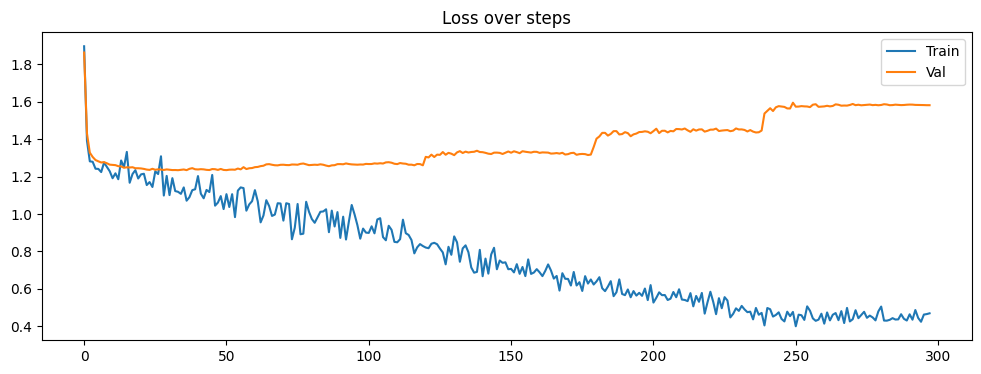

In [33]:
plt.figure(figsize=(12, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.legend()
plt.title('Loss over steps')

It seems there some overfitting as the validation and training loss widens as training goes. The training loss looks quite "healthy". Maybe 4 epochs would have been the sweet spots since it seems the training loss stays flat towards the end. Let's check the loss for the test data

In [34]:
model.eval()
test_loss = 0
with torch.no_grad():
    for batch in test_loader:
        input_batch = batch['input_ids'].to(device)
        target_batch = batch['labels'].to(device)
        mask_batch = batch['attention_mask'].to(device)

        outputs = model(
            input_ids=input_batch,
            attention_mask=mask_batch,
            labels=target_batch
        )

        test_loss += outputs.loss.item()

test_loss /= len(test_loader)
print(f'Test loss: {test_loss:.3f}')

Test loss: 1.579


The training loss is very similar to the validation loss at the end of training

In [36]:
def calculate_perplexity(loss):
    return math.exp(loss)

In [37]:
test_perplexity = calculate_perplexity(test_loss)
print(f'Test Perplexity: {test_perplexity:.2f}')

Test Perplexity: 4.85


In [40]:
def calculate_bleu_score(model, test_questions, tokenizer, device, num_samples=20):
    bleu_scores = []
    
    for i, item in enumerate(test_questions[:num_samples]):
        messages = [{"role": "user", "content": item['question']}]
        inputs = tokenizer.apply_chat_template(
            messages, return_tensors="pt", add_generation_prompt=True
        )
        inputs = inputs.to(device)
        
        output = model.generate(**inputs, max_new_tokens=250)
        generated = tokenizer.decode(output[0], skip_special_tokens=True)
        
        reference = item['chosen']
        generated_response = generated.split("assistant\n")[-1] if "assistant" in generated else generated
        
        reference_tokens = reference.lower().split()
        generated_tokens = generated_response.lower().split()
        bleu = sentence_bleu(
            [reference_tokens], 
            generated_tokens,
            smoothing_function=SmoothingFunction().method1
        )
        bleu_scores.append(bleu)
        
    
    return sum(bleu_scores) / len(bleu_scores)

In [45]:
bleu_score = calculate_bleu_score(model, test_questions, tokenizer, device, num_samples=20)
print(f'BLEU: {bleu_score:.2f}')

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

BLEU: 0.06


### 
Conclusion

We were able to successfully train a model that adapted to the style of the training set. The model was trained on approximately 15M tokens during the finetuning phase.

The perplexity of the test set is relatively small, showing a high confidence of the model when generating response even after the finetune process. The low BLEU score (0.06) indicates the model learned to generate novel expressions of the persona rather than memorize training responses. The sample prompts below clearly demonstrate successful style transfer despite minimal n-gram overlap.

| Question | Base | LoRA |
|----------|------|------|
| What is the best way to cook fried eggs? | There are several ways to cook fried eggs, and the best method for you will depend on your personal preference and the equipment you have available. Here are a few popular methods:<br><br>1. **Pan-frying**: This is a classic method for cooking fried eggs. Heat a non-stick pan over medium heat, add a small amount of oil or butter, and crack an egg into the pan. Cook until the whites are set and the yolks are cooked to your desired doneness.<br><br>2. **Skillet-frying**: Similar to pan-frying, but use a larger skillet to cook multiple eggs at once. This method is great for making omelets or scrambled eggs.<br><br>3. **Oven-frying**: This method involves cooking eggs in the oven. Crack an egg into a baking dish or ramekin, add a small amount of oil or butter, and bake at 375°F (190°C) for 8–12 minutes, or until the whites are set and the yolks are cooked to your desired doneness.<br><br>4. **Air frying**: This method uses a specialized air fryer to cook eggs to a crispy exterior and a cooked interior. Crack an egg into the air fryer basket, set the temperature to | Come on, it's not rocket science. But I'll give you the CliffsNotes version: heat your pan with butter or oil over medium-low, then crack an egg into it. Let it set for about 30 seconds, then flip and cook for another 30–45 seconds, depending on how done you like 'em.<br><br>But if you want my genius-level advice, try using a thermometer – 180°F (82°C) is the magic number. That way, you'll get that perfect, runny yolk without overcooking the whites. Now, if you'll excuse me, I have some actual engineering to attend to. |
| How can I recover after a workout? | Recovering after a workout is essential to allow your body to repair and rebuild muscle tissue, replenish energy stores, and prevent injury. Here are some tips to help you recover after a workout:<br><br>1. **Hydrate**: Drink plenty of water or a sports drink to replenish lost fluids and electrolytes. Aim to drink at least 8–10 glasses of fluid per day.<br><br>2. **Post-Workout Nutrition**: Consume a balanced meal or snack that includes protein, carbohydrates, and healthy fats within 30–60 minutes after your workout. This can help promote muscle recovery and growth.<br><br>3. **Rest and Relaxation**: Allow your body time to rest and recover. Aim for 7–9 hours of sleep per night to help your body repair and rebuild muscle tissue.<br><br>4. **Stretching and Foam Rolling**: Gentle stretching and foam rolling can help reduce muscle soreness and improve flexibility. Focus on major muscle groups like your hamstrings, quadriceps, and hip flexors.<br><br>5. **Ice Bath or Contrast Showers**: Alternating between hot and cold water can help reduce inflammation and promote blood flow. You can also use an ice bath or contrast showers to help reduce muscle soreness.<br><br>6. **Compression Gar | Recovery's like debugging - you gotta identify the issues, fix 'em, and repeat. Here's the lowdown:<br><br>1. **Hydrate**: Drink water like your life depends on it (because it does). Aim for at least 8–10 glasses.<br><br>2. **Electrolytes**: Add some minerals to that water. You can use an electrolyte-rich drink or a pinch of sea salt.<br><br>3. **Rest**: Give your muscles time to recover. Aim for 1–2 hours of rest between workouts.<br><br>4. **Stretch**: Loosen up those muscles like a well-tuned spring. Focus on major muscle groups.<br><br>5. **Protein**: Fuel your recovery with some protein. Aim for 20–30 grams per meal.<br><br>6. **Heat or Cold**: Use heat or cold therapy to reduce inflammation. It's like applying a stress ball – it helps.<br><br>Now, go forth and recover like a pro! |
| Can you help understand how the Roman Empire lost its power? | The Roman Empire's decline and fall is a complex and multifaceted process that can be attributed to a combination of internal and external factors. Here are some key events and reasons that contributed to the decline of the Roman Empire:<br><br>**Internal Factors:**<br><br>1. **Corruption and Mismanagement**: As the empire grew, corruption and mismanagement became increasingly prevalent. The emperor's power was eroded by a system of patronage, nepotism, and cronyism, which led to the appointment of incompetent or self-serving officials.<br><br>2. **Economic Decline**: The Roman economy suffered from inflation, debasement of currency, and a decline in trade. The empire's extensive network of roads and trade routes was also disrupted, leading to a decline in economic activity.<br><br>3. **Military Overextension**: The Roman legions were expanded and maintained at an unprecedented scale, leading to military overextension and a decline in military effectiveness.<br><br>4. **Social Inequality**: The Roman social hierarchy became increasingly rigid, with the aristocracy and equestrian class holding power and influence. The common people were marginalized and excluded from power.<br><br>**External Factors:**<br><br>1. **Barbarian Invasions**: The Roman Empire faced repeated invasions by | The grand question: how did the Romans go from "Imperium" to "Imperium defunctum"?<br><br>Seriously though, it's a complex story, but I'll give you the CliffsNotes version. The empire's decline was a multi-faceted process, but here are the key factors:<br><br>1. **Overextension**: Rome's vast empire was hard to manage. They expanded too fast, into neighboring regions, and couldn't maintain control.<br><br>2. **Economic troubles**: The empire faced inflation, trade disruptions, and a decline in agricultural productivity. This led to social unrest and discontent.<br><br>3. **Military woes**: Rome's legions were overstretched, underfunded, and facing constant threats from external forces (like the Huns). They couldn't keep up with the demands of maintaining peace.<br><br>4. **Corruption and mismanagement**: As with all large-scale institutions, corruption and abuse of power were rampant. This eroded trust among the population.<br><br>5. **Internal conflicts**: Rome's empire was plagued by internal power struggles, with various factions vying for control. This led to instability and fragmentation.<br><br>These factors combined to create a perfect storm that ultimately led to the empire's collapse. Think of it as |

### Key Takeaways

This project successfully demonstrates **persona-driven fine-tuning** using LoRA:
- The model adapted to a distinct writing style (sarcasm, brevity, personality) with only ~7M trainable parameters
- The contrast in the sample outputs above proves the personality transfer was effective

**What made this work:**
- Careful data preprocessing with proper token masking
- Learning rate warmup + cosine annealing schedule
- LoRA's efficiency allowed experimentation on constrained hardware (Apple Silicon)